#Module 6





# Day 21 — Environment Setup


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Environment ready.")

Environment ready.


# Load the Real-World Dataset



In [5]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"
zip_path = "/content/student_performance.zip"
extract_path = "/content/student_performance"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# The extracted content contains another zip file named 'student.zip'
# which holds the actual CSVs. Extract this secondary zip file.
secondary_zip_path = os.path.join(extract_path, "student.zip")
if os.path.exists(secondary_zip_path):
    with zipfile.ZipFile(secondary_zip_path, "r") as secondary_zip_ref:
        secondary_zip_ref.extractall(extract_path)

csv_path = None
for root, dirs, files in os.walk(extract_path):
    if "student-mat.csv" in files:
        csv_path = os.path.join(root, "student-mat.csv")
        break

df = pd.read_csv(csv_path, sep=";")

print("Dataset loaded.")
print("Shape:", df.shape)
df.head()

Dataset loaded.
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Data Understanding


In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,395,2,GP,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,395,2,F,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,395.0,NaN,NaN,NaN,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
address,395,2,U,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,395,2,GT3,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,395,2,T,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,395.0,NaN,NaN,NaN,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,NaN,NaN,NaN,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
Mjob,395,5,other,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,395,5,other,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Day 21 — Data Quality Check


In [8]:
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


## Clean the Dataset



In [9]:
df_clean = df.drop_duplicates().copy()

df_clean["Pass"] = np.where(df_clean["G3"] >= 10, 1, 0)

print("Rows after cleaning:", len(df_clean))
print(df_clean["Pass"].value_counts())

Rows after cleaning: 395
Pass
1    265
0    130
Name: count, dtype: int64


# Day 22 — Exploratory Data Analysis


## Pass / Fail Distribution


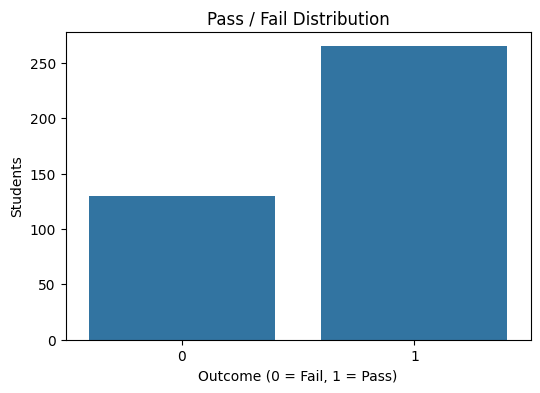

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Pass")
plt.title("Pass / Fail Distribution")
plt.xlabel("Outcome (0 = Fail, 1 = Pass)")
plt.ylabel("Students")
plt.show()

## Final Grade Distribution


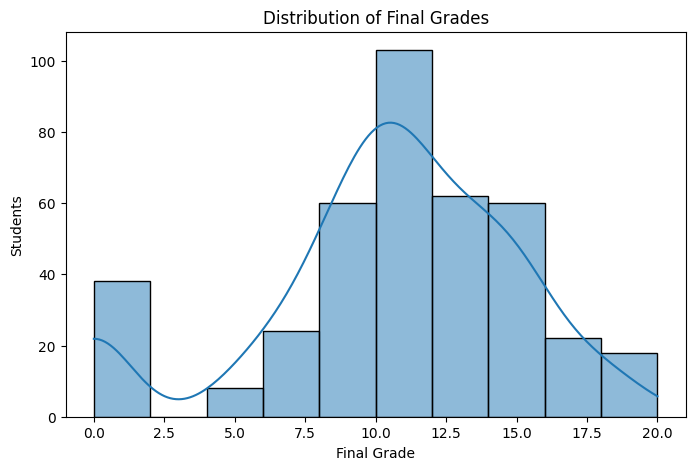

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["G3"], bins=10, kde=True)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Students")
plt.show()

## Study Time vs Pass Rate


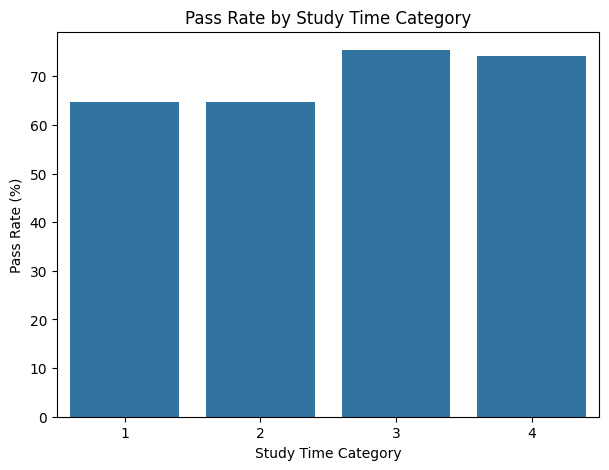

,studytime,Pass_Rate
0,1,64.761905
1,2,64.646465
2,3,75.384615
3,4,74.074074


In [12]:
study_pass = (
    df_clean.groupby("studytime")["Pass"]
    .mean()
    .mul(100)
    .reset_index(name="Pass_Rate")
)

plt.figure(figsize=(7,5))
sns.barplot(data=study_pass, x="studytime", y="Pass_Rate")
plt.title("Pass Rate by Study Time Category")
plt.xlabel("Study Time Category")
plt.ylabel("Pass Rate (%)")
plt.show()

study_pass

## Previous Failures vs Pass Rate


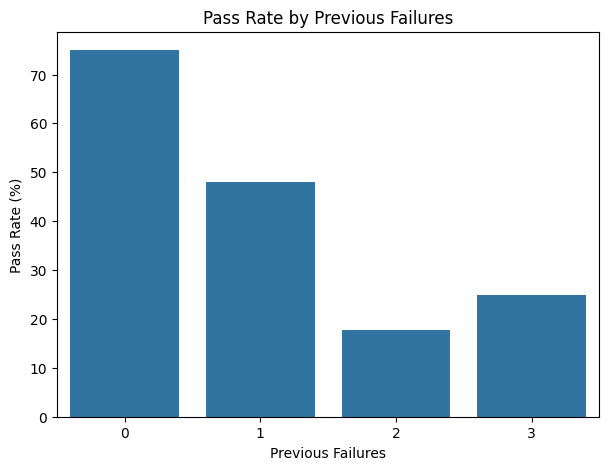

,failures,Pass_Rate
0,0,75.000000
1,1,48.000000
2,2,17.647059
3,3,25.000000


In [13]:
failure_pass = (
    df_clean.groupby("failures")["Pass"]
    .mean()
    .mul(100)
    .reset_index(name="Pass_Rate")
)

plt.figure(figsize=(7,5))
sns.barplot(data=failure_pass, x="failures", y="Pass_Rate")
plt.title("Pass Rate by Previous Failures")
plt.xlabel("Previous Failures")
plt.ylabel("Pass Rate (%)")
plt.show()

failure_pass

## Absences vs Final Grade


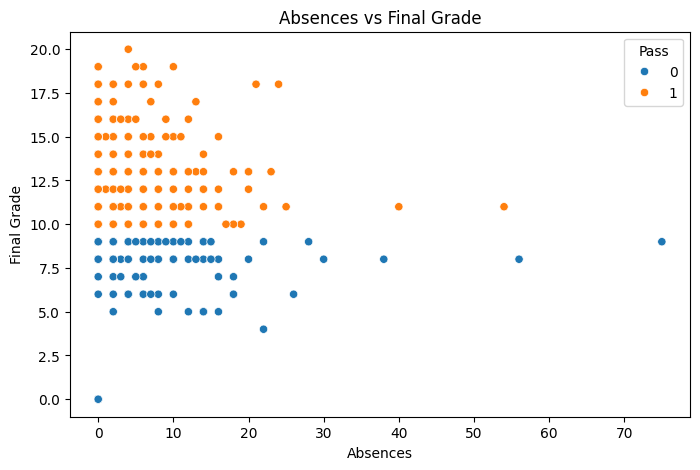

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="absences", y="G3", hue="Pass")
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.show()

## Higher Education Aspiration vs Pass Rate


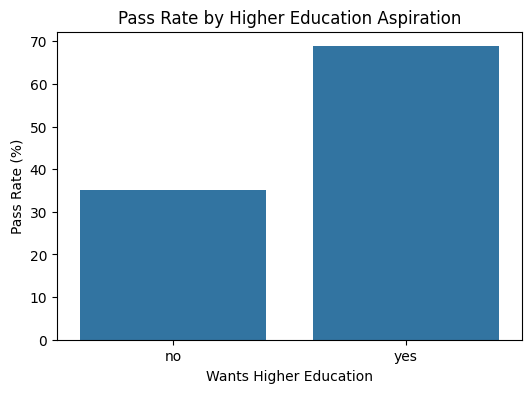

,higher,Pass_Rate
0,no,35.0
1,yes,68.8


In [15]:
higher_pass = (
    df_clean.groupby("higher")["Pass"]
    .mean()
    .mul(100)
    .reset_index(name="Pass_Rate")
)

plt.figure(figsize=(6,4))
sns.barplot(data=higher_pass, x="higher", y="Pass_Rate")
plt.title("Pass Rate by Higher Education Aspiration")
plt.xlabel("Wants Higher Education")
plt.ylabel("Pass Rate (%)")
plt.show()

higher_pass

## Correlation Heatmap for Numerical Variables


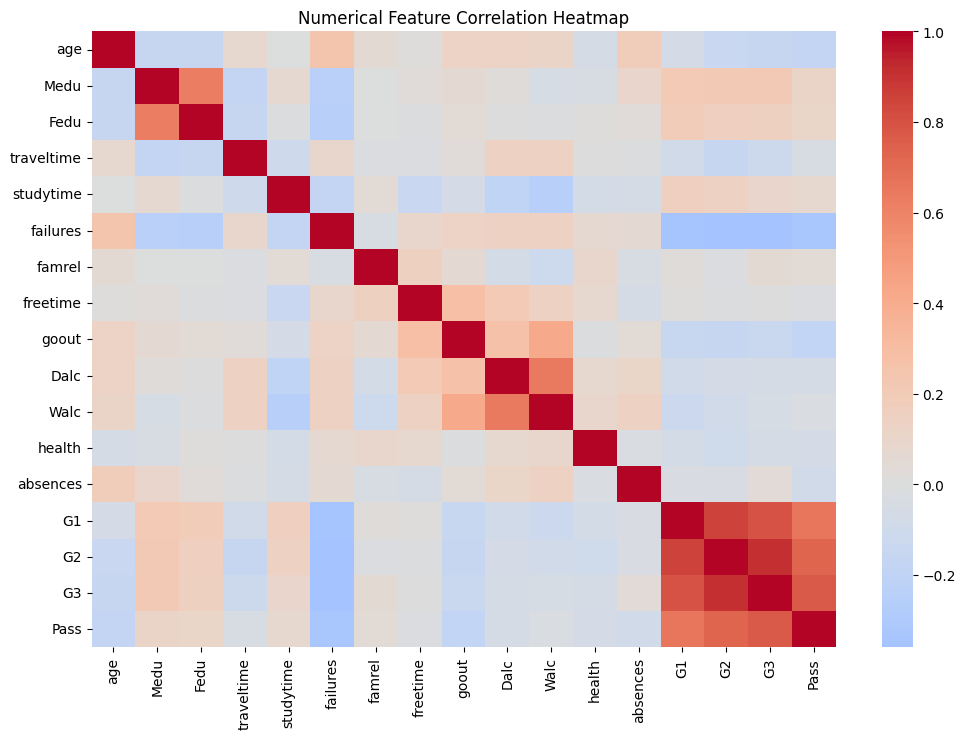

In [16]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,8))
sns.heatmap(
    df_clean[numeric_cols].corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Numerical Feature Correlation Heatmap")
plt.show()

# Day 23 — Feature Preparation

In [17]:
model_df = df_clean.drop(columns=["G1", "G2", "G3"])

X = model_df.drop(columns=["Pass"])
y = model_df["Pass"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))
print("Total features before encoding:", X.shape[1])

Categorical features: 17
Numerical features: 13
Total features before encoding: 30


## Train/Test Split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 316
Testing samples: 79


## Preprocessing Pipeline


In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


# Model 1 — Logistic Regression


In [20]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


## Logistic Regression Evaluation


In [21]:
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_pred),
    "Precision": precision_score(y_test, logistic_pred),
    "Recall": recall_score(y_test, logistic_pred),
    "F1": f1_score(y_test, logistic_pred),
    "ROC_AUC": roc_auc_score(y_test, logistic_prob)
}

for metric, value in logistic_metrics.items():
    print(metric, ":", round(value, 3))

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))

Accuracy : 0.658
Precision : 0.717
Recall : 0.811
F1 : 0.761
ROC_AUC : 0.589

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.35      0.40        26
           1       0.72      0.81      0.76        53

    accuracy                           0.66        79
   macro avg       0.60      0.58      0.58        79
weighted avg       0.64      0.66      0.64        79



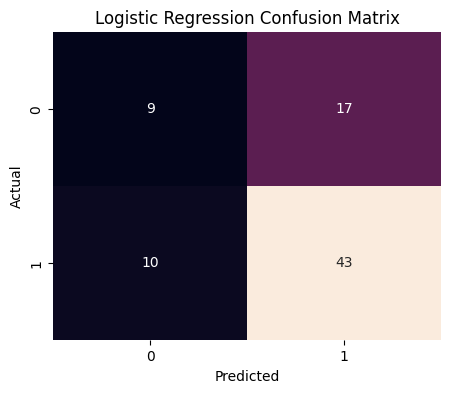

In [22]:
cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model 2 — Random Forest


In [23]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest trained.")

Random Forest trained.


## Random Forest Evaluation


In [24]:
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC_AUC": roc_auc_score(y_test, rf_prob)
}

for metric, value in rf_metrics.items():
    print(metric, ":", round(value, 3))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy : 0.684
Precision : 0.7
Recall : 0.925
F1 : 0.797
ROC_AUC : 0.647

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.19      0.29        26
           1       0.70      0.92      0.80        53

    accuracy                           0.68        79
   macro avg       0.63      0.56      0.54        79
weighted avg       0.65      0.68      0.63        79



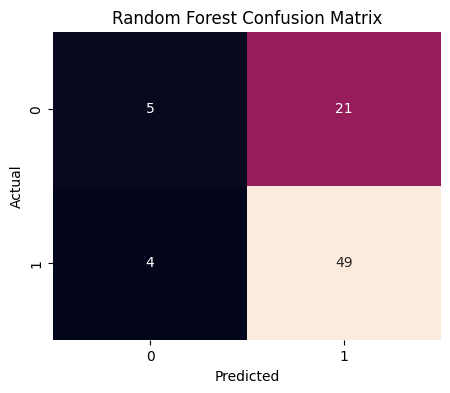

In [25]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cbar=False)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Day 23 — Model Comparison


In [26]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    "Logistic Regression": [
        logistic_metrics["Accuracy"],
        logistic_metrics["Precision"],
        logistic_metrics["Recall"],
        logistic_metrics["F1"],
        logistic_metrics["ROC_AUC"]
    ],
    "Random Forest": [
        rf_metrics["Accuracy"],
        rf_metrics["Precision"],
        rf_metrics["Recall"],
        rf_metrics["F1"],
        rf_metrics["ROC_AUC"]
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.658228,0.683544
1,Precision,0.716667,0.700000
2,Recall,0.811321,0.924528
3,F1,0.761062,0.796748
4,ROC_AUC,0.588534,0.647315


# Day 24 — Feature Importance




In [27]:
rf_model = rf_pipeline.named_steps["model"]
ohe = rf_pipeline.named_steps["preprocess"].named_transformers_["cat"]

encoded_cat_names = ohe.get_feature_names_out(categorical_features)

feature_names = numeric_features + encoded_cat_names.tolist()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
12,absences,0.075375
5,failures,0.074174
8,goout,0.046246
0,age,0.043523
11,health,0.037908
7,freetime,0.034499
10,Walc,0.034375
1,Medu,0.033000
6,famrel,0.032622
2,Fedu,0.032524


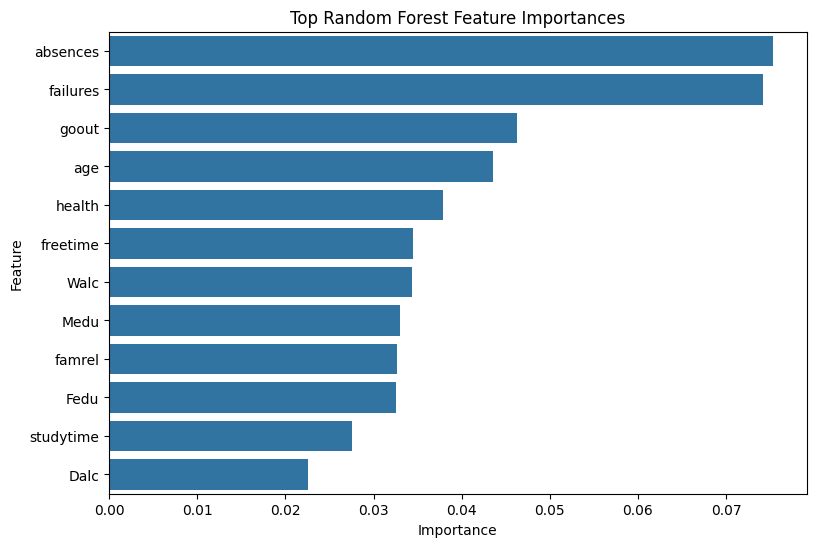

In [28]:
top_features = importance_df.head(12)

plt.figure(figsize=(9,6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title("Top Random Forest Feature Importances")
plt.show()

# Export Project Outputs


In [29]:
df_clean.to_csv("student_performance_final_cleaned.csv", index=False)
comparison.to_csv("model_comparison.csv", index=False)
importance_df.to_csv("feature_importance.csv", index=False)

print("Exported:")
print("- student_performance_final_cleaned.csv")
print("- model_comparison.csv")
print("- feature_importance.csv")

Exported:
- student_performance_final_cleaned.csv
- model_comparison.csv
- feature_importance.csv
